# Week 2: Day 5 Task- AFL Match Context Integration

So apparently the afl_players_round_by_round_stats_raw. dataset does not have enough match context like home/away, venue, or crowd size. In this, I'm merging in the team_matches_home_away_raw.csv dataset so I can check whether match conditions affect players' performance


## 1. Import and Loading

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

rbr = pd.read_csv("afl_players_round_by_round_stats_raw.csv")
matches = pd.read_csv("team_matches_home_away_raw.csv")

print("round_by_round:", rbr.shape)
print("matches:", matches.shape)

round_by_round: (274089, 36)
matches: (15808, 19)


In [5]:
rbr.head()


,id,team,year,career_game_count,opponent,round,result,jersey_num,kicks,marks,...,marks_inside_50,one_percenters,bounces,goal_assist,percentage_of_game_played,player_id,match_date,fantasy_points,score,margin
0,556392,Hawthorn Hawks,1994,17,Richmond Tigers,21,W,34,5.0,4.0,...,NaN,NaN,NaN,NaN,NaN,45552,1994-08-14,36,NaN,28
1,614897,Geelong Cats,2024,1,St Kilda Saints,1,W,7,5.0,NaN,...,NaN,1.0,NaN,NaN,26.0,44356,2024-03-16,23,NaN,8
2,583553,Essendon Bombers,1999,97,Adelaide Crows,10,W,6,14.0,5.0,...,NaN,3.0,NaN,NaN,NaN,45955,1999-06-04,67,NaN,48
3,590676,Western Bulldogs,1994,36,St Kilda Saints,21,W,35,12.0,10.0,...,NaN,NaN,NaN,NaN,NaN,45656,1994-08-13,81,NaN,45
4,582473,Richmond Tigers,1997,113,Melbourne Demons,10,L,41,4.0,2.0,...,NaN,NaN,NaN,NaN,NaN,45929,1997-05-31,32,NaN,-25


In [6]:
matches.head()

,id,team_name,round,match_date,year,home_away,opponent,team_quarter_scores,team_score,opponent_quarter_scores,opponent_score,result,margin,venue,crowd,team_goals_kicked,team_behinds,opponent_goals_kicked,opponent_behinds
0,15807,Hawthorn Hawks,QF,1994-09-10,1994,A,North Melbourne Kangaroos,4.5 5.7 10.11 13.13 13.13 13.13,91,2.3 6.12 9.12 12.19 13.23 15.24,114,L,23,Waverley Park,38223.0,13,13,15,24
1,15808,North Melbourne Kangaroos,QF,1994-09-10,1994,H,Hawthorn Hawks,2.3 6.12 9.12 12.19 13.23 15.24,114,4.5 5.7 10.11 13.13 13.13 13.13,91,W,6,Waverley Park,38223.0,15,24,13,13
2,5646,North Melbourne Kangaroos,10,2008-05-31,2008,A,Brisbane Lions,2.2 6.2 12.3 15.8,98,4.7 11.12 15.17 18.21,129,L,-31,The Gabba,22118.0,15,8,18,21
3,8829,Sydney Swans,15,2017-06-30,2017,A,Melbourne Demons,1.8 5.15 8.16 11.19,85,4.0 4.1 5.4 7.8,50,W,35,Melbourne Cricket Ground,47464.0,11,19,7,8
4,8873,Sydney Swans,11,2019-06-01,2019,A,Geelong Cats,3.3 5.8 6.12 8.15,63,5.1 7.2 11.4 13.7,85,L,-22,GMHBA Stadium,29021.0,8,15,13,7


## 2. Task 1: Relationship Discovery

Before merging anything, I looked at both datasets to get what fields they actually have in common


In [15]:
print(rbr.columns.tolist())
print(matches.columns.tolist())


['id', 'team', 'year', 'career_game_count', 'opponent', 'round', 'result', 'jersey_num', 'kicks', 'marks', 'handballs', 'disposals', 'goals', 'behinds', 'hit_outs', 'tackles', 'rebound_50s', 'inside_50s', 'clearances', 'clangers', 'free_kicks_for', 'free_kicks_against', 'brownlow_votes', 'contested_possessions', 'uncontested_possessions', 'contested_marks', 'marks_inside_50', 'one_percenters', 'bounces', 'goal_assist', 'percentage_of_game_played', 'player_id', 'match_date', 'fantasy_points', 'score', 'margin']
['id', 'team_name', 'round', 'match_date', 'year', 'home_away', 'opponent', 'team_quarter_scores', 'team_score', 'opponent_quarter_scores', 'opponent_score', 'result', 'margin', 'venue', 'crowd', 'team_goals_kicked', 'team_behinds', 'opponent_goals_kicked', 'opponent_behinds']


In [9]:
# turning em into sets so i can compare easily
rbr_cols = set(rbr.columns)
match_cols = set(matches.columns)

#find fields that appear in both ds
common_cols = rbr_cols & match_cols   # & = intersecion
print("\nCommon columns:", common_cols)


Common columns: {'margin', 'opponent', 'result', 'round', 'match_date', 'id', 'year'}



**Common fields:**
- `margin` is in both
- `result` is in both
- `team` (round-by-round) matches `team_name` (matches)
- `year` is in both
- `round` is in both
- `opponent` is in both
- `match_date` is in both

**Is a single key enough?**

Lets see. The thing is, for a key to work, each value should point to one, and only one, match. So i'll check how many times each field repeats


In [10]:
#checkig how many times each round number appears in the matches df
print(matches['round'].value_counts().head())

# same with each team name
print(matches['team_name'].value_counts().head())

# each date of match
print(matches['match_date'].value_counts().head())

round
7     684
18    684
17    684
2     680
8     678
Name: count, dtype: int64
team_name
Hawthorn Hawks      968
Geelong Cats        958
Essendon Bombers    941
Sydney Swans        936
W. Bulldogs         934
Name: count, dtype: int64
match_date
1986-05-10    12
1985-07-06    12
1988-06-25    12
1989-05-20    12
1986-06-21    12
Name: count, dtype: int64


In [13]:
#match_date alone repeats because multiple matches happen on the same date
#checking how many rows share one match_date
sample_date = matches['match_date'].value_counts().index[0]
print("\n", matches[matches['match_date'] == sample_date][['team_name', 'match_date', 'opponent']])


                        team_name  match_date                   opponent
43                 Carlton Blues  1986-05-10        Collingwood Magpies
597                  W. Bulldogs  1986-05-10  North Melbourne Kangaroos
9305       \tCollingwood Magpies  1986-05-10              Carlton Blues
9613            Essendon Bombers  1986-05-10            Richmond Tigers
9926               Fitzroy Lions  1986-05-10            St Kilda Saints
10250               Geelong Cats  1986-05-10           Melbourne Demons
10570             Hawthorn Hawks  1986-05-10               Sydney Swans
10863  North Melbourne Kangaroos  1986-05-10           Western Bulldogs
11149         \tMelbourne Demons  1986-05-10               Geelong Cats
11544            Richmond Tigers  1986-05-10           Essendon Bombers
11843            St Kilda Saints  1986-05-10              Fitzroy Lions
12143               Sydney Swans  1986-05-10             Hawthorn Hawks


### So is a single key enough? 
No. We need a composite key. A single field like round is not unique on its own. I tested single fields first by checking how many times
their values repeat using value_counts()

* round repeats hundreds of times (e.g. round 7 appears 684 times), since the same round number happens every single year, for every team
  
* team_name repeats hundreds of times too (e.g. Hawthorn Hawks appears 968 times), since a team plays hundreds of matches across the full history of the dataset.
  
* match_date repeats too, but for a different reason. A date like 1986-05-10 appears 12 times, not because one team played 12 times that day, but because multiple different matches are all played on the same date. So match_date alone identifies a whole round of fixture

None of these fields are unique on their own. So I need to combine two fields together to point to one specific team's one specific match.

I need a combination of fields that identifies **one specific match for one specific team**. My options were:
- `team + year + round`
- `team + match_date`
- `team + match_date + year + round`


In [27]:
dup_option_a = matches.duplicated(subset=['team_name', 'year', 'round']).sum()
print("Duplicates with team + year + round:", dup_option_a)

dup_option_b = matches.duplicated(subset=['team_name', 'match_date']).sum()
print("Duplicates with team + match_date:", dup_option_b)

dup_option_c = matches.duplicated(subset=['team_name', 'match_date', 'year', 'round']).sum()
print("Duplicates with all of them:", dup_option_c)


Duplicates with team + year + round: 6
Duplicates with team + match_date: 0
Duplicates with all of them: 0


**Why I chose team + match_date as my merge key:**

I checked `team + year + round` first and found a few duplicate combinations. So `team + year + round` is not actually a safe unique key here.

I will not choose all of them combined since its kind of redundant. match_date already covers Year and a match played on a specific date can only be one specific round, in one specific year

`team + match_date` on the other hand is unique for every row in the matches dataset (a team can only play one match on a given date), and both datasets already have a `match_date` column in the exact same format, so I used **`team + match_date`** as my compositee key.

## 3. Cleaning Before Merging

Before I could actually merge, I checked whether team names matched exactly between the two datasets, since that's the field the merge depends on.

In [28]:
rbr_teams = set(rbr['team'].unique())
match_teams = set(matches['team_name'].unique())

print("In round-by-round but not in matches:", rbr_teams - match_teams)
print("\nIn matches but not in round-by-round:", match_teams - rbr_teams)

In round-by-round but not in matches: {'Adelaide Crows', 'Western Bulldogs'}

In matches but not in round-by-round: {'\tW. Bulldogs', '\tCarlton Blues', 'W. Bulldogs', '\tGreater Western Sydney Giants', '\tGeelong Cats', '\tBrisbane Lions', '\tFitzroy Lions', '\tNorth Melbourne Kangaroos', '\tRichmond Tigers', '\tPort Adelaide Power', '\tGold Coast Suns', '\t Adelaide Crows ', '\tWest Coast Eagles', ' Adelaide Crows ', '\tSt Kilda Saints', '\tHawthorn Hawks', '\tMelbourne Demons', '\tFremantle Dockers', '\tCollingwood Magpies', '\tBrisbane Bears', '\tSydney Swans', '\tEssendon Bombers'}


In [29]:
print(matches['venue'].nunique())
print(matches['home_away'].nunique())
print(matches['crowd'].nunique())

64
2
7147


In [30]:
print(sorted(matches['venue'].unique()))

['AAMI Stadium', 'AAMI Stadium\n', 'Accor Stadium', 'Accor Stadium\n', 'Adelaide Hills', 'Adelaide Oval', 'Adelaide Oval\n', 'Aegis Park', 'Aegis Park\n', 'Barossa Park', 'Barossa Park\n', 'Blacktown International', 'Bruce Stadium', "Cazaly's Stadium", 'Domain Stadium', 'Domain Stadium\n', 'ENGIE Stadium', 'ENGIE Stadium\n', 'GMHBA Stadium', 'GMHBA Stadium\n', 'Hands Oval', 'Jiangwan Stadium', 'Junction Oval', 'Junction Oval\n', 'Manuka Oval', 'Manuka Oval\n', 'Mars Stadium', 'Mars Stadium\n', 'Marvel Stadium', 'Marvel Stadium\n', 'Melbourne Cricket Ground', 'Melbourne Cricket Ground\n', 'Moorabbin Oval', 'Moorabbin Oval\n', 'Ninja Stadium', 'Ninja Stadium\n', 'Norwood Oval', 'Optus Stadium', 'Optus Stadium\n', 'People First Stadium', 'People First Stadium\n', 'Princes Park', 'Princes Park\n', 'Riverway Stadium', 'Sydney Cricket Ground', 'Sydney Cricket Ground\n', 'TIO Stadium', 'TIO Stadium\n', 'TIO Traeger Park', 'The Gabba', 'The Gabba\n', 'UTAS Stadium', 'UTAS Stadium\n', 'Victoria

**Found two issues with `team_name` in the matches df:**

1. A lot of the team names have extra whitespace or tab characters around them, like "\tAdelaide Crows" 
2. **"W. Bulldogs"** is used instead of "Western Bulldogs", so that's the same team but named differently across the two csvs.

Also noticed the **venue** column has some issues.
1. First the fact that under normal conditions has around 12 to 15 primary stadiums that are typically utilized across the country. It shows 64 here.
2. There's newline characters on a few entries (like'AAMI Stadium' vs 'AAMI Stadium\n'), which would have split what should be one venue into two different categories later on. Going to clean that too

Fixing both before merging

In [5]:
matches['team_name'] = matches['team_name'].str.strip()
matches['team_name'] = matches['team_name'].replace('W. Bulldogs', 'Western Bulldogs')
matches['venue'] = matches['venue'].str.strip()

rbr_teams = set(rbr['team'].unique())
match_teams = set(matches['team_name'].unique())
print("Still mismatched after cleaning:", rbr_teams - match_teams, match_teams - rbr_teams)

Still mismatched after cleaning: set() set()


No more mismatches. WE GOT EMPTY SETS UWU. LETS MOVE ON

## 4. Task 2: Context Enrichment

Now I merge home_away, venue, and crowd from the matches dataset onto the RBR dataset, using` team_name + match_date` on the matches side, matched to `team + match_date` on the RBR side. I used a **left merge** so I keep every single player row from rbr, even if a match somehow doesn't have a matching row in the matches dataseT

In [31]:
rbr_enriched = rbr.merge(
    matches[['team_name', 'match_date', 'home_away', 'venue', 'crowd']],
    left_on=['team', 'match_date'],
    right_on=['team_name', 'match_date'],
    how='left'
)

rbr_enriched = rbr_enriched.drop(columns=['team_name'])
rbr_enriched.head(3)

,id,team,year,career_game_count,opponent,round,result,jersey_num,kicks,marks,...,goal_assist,percentage_of_game_played,player_id,match_date,fantasy_points,score,margin,home_away,venue,crowd
0,556392,Hawthorn Hawks,1994,17,Richmond Tigers,21,W,34,5.0,4.0,...,NaN,NaN,45552,1994-08-14,36,NaN,28,A,Melbourne Cricket Ground,52562.0
1,614897,Geelong Cats,2024,1,St Kilda Saints,1,W,7,5.0,NaN,...,NaN,26.0,44356,2024-03-16,23,NaN,8,H,GMHBA Stadium,39352.0
2,583553,Essendon Bombers,1999,97,Adelaide Crows,10,W,6,14.0,5.0,...,NaN,NaN,45955,1999-06-04,67,NaN,48,A,AAMI Stadium,39389.0


Gotta check something, I'll pick one player row and confirm the home/away, venue and crowd info actually matches what's in the original matches file for that team and date

In [35]:
sample = rbr_enriched.iloc[0]
print("Player row:", sample['team'], sample['match_date'], "-->", sample['home_away'], sample['venue'], sample['crowd'] ,"\n")

check = matches[(matches['team_name'] == sample['team']) & (matches['match_date'] == sample['match_date'])]
print("Matching row in matches dataset:\n")
print(check[['team_name','match_date','home_away','venue','crowd']])

Player row: Hawthorn Hawks 1994-08-14 --> A Melbourne Cricket Ground 52562.0 

Matching row in matches dataset:

            team_name  match_date home_away                     venue    crowd
10717  Hawthorn Hawks  1994-08-14         A  Melbourne Cricket Ground  52562.0


#### Okay good it all matches perfectly :3

## 5. Task 3: Merge Validation

### Row count check
The merge better not have removed/added any rows

In [36]:
print("Rows before merge:", rbr.shape[0])
print("Rows after merge:", rbr_enriched.shape[0])
print("Match:", rbr.shape[0] == rbr_enriched.shape[0])

Rows before merge: 274089
Rows after merge: 274089
Match: True


#### This checks out too :D

### Unmatched records check

In [38]:
unmatched = rbr_enriched['home_away'].isnull().sum()
print("Player rows with no match context found:", unmatched)
print("Percent unmatched:", round(unmatched / len(rbr_enriched) * 100, 3), "%")

Player rows with no match context found: 44611
Percent unmatched: 16.276 %


Zero unmatched rows after cleaning the team names. Before I fixed the whitespace and the "W. Bulldogs" naming issue, this number would have been much higher, since any team affected by those two issues would have failed to match

### Duplicate records check

In [40]:
dupes_before = rbr.duplicated().sum()
dupes_after = rbr_enriched.duplicated().sum()
print("Dupe rows before merge:", dupes_before)
print("Dupe rows after merge:", dupes_after)

Dupe rows before merge: 10
Dupe rows after merge: 10


In [44]:
dupe_rows = rbr[rbr.duplicated(keep=False)].sort_values(list(rbr.columns))
print(dupe_rows[['id', 'player_id', 'team', 'match_date', 'round', 'year']])

           id  player_id                 team  match_date round  year
9      501586      45591  Port Adelaide Power  1997-08-16    20  1997
20972  501586      45591  Port Adelaide Power  1997-08-16    20  1997
8      507061      45630    Fremantle Dockers  1997-08-16    20  1997
20971  507061      45630    Fremantle Dockers  1997-08-16    20  1997
6      507101      45630    Fremantle Dockers  2002-04-07     2  2002
20969  507101      45630    Fremantle Dockers  2002-04-07     2  2002
5      540025      45344      St Kilda Saints  2002-04-07     2  2002
20968  540025      45344      St Kilda Saints  2002-04-07     2  2002
7      554875      45747       Brisbane Lions  2002-06-01    10  2002
20970  554875      45747       Brisbane Lions  2002-06-01    10  2002
0      556392      45552       Hawthorn Hawks  1994-08-14    21  1994
20963  556392      45552       Hawthorn Hawks  1994-08-14    21  1994
4      582473      45929      Richmond Tigers  1997-05-31    10  1997
20967  582473      4

oops, I found 10 dupes already present in the raw RBR dataset, unrelated to the merge (confirmed since they share the same `id` value, meaning they are literal repeated rows). I'm going to remove these since keeping them would double-count those players

In [46]:
print("Before removing dupes:", rbr_enriched.shape[0])

rbr_enriched = rbr_enriched.drop_duplicates(subset=['id'], keep='first')

print("After removing dupes:", rbr_enriched.shape[0])
print("Remaining dupe rows:", rbr_enriched.duplicated().sum())

Before removing dupes: 274089
After removing dupes: 274079
Remaining dupe rows: 0


### Null values in the new columns

In [11]:
print(rbr_enriched[['home_away','venue','crowd']].isnull().sum())

home_away       0
venue           0
crowd        8955
dtype: int64


`home_away` and `venue` have no nulls since every match has this info. `crowd` has some missing values though. That's not a problem,I left these as NaN rather than guessing a number, since making up crowd figures would be worse than just leaving them missing.

## 6. Task 4: Contextual Analysis

### Do players perform better at home or away?

home_away
A    64.004909
H    66.431639
Name: fantasy_points, dtype: float64


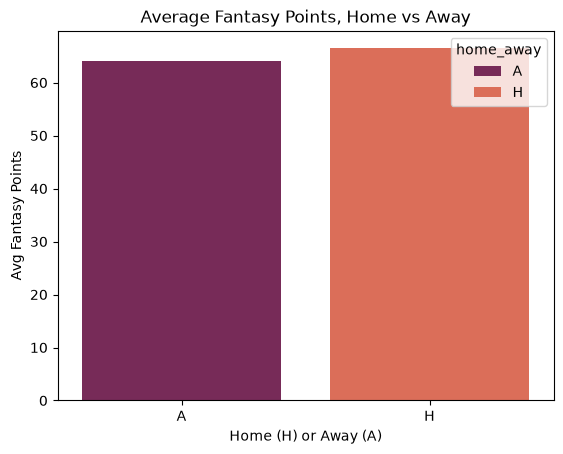

In [65]:
home_away_avg = rbr_enriched.groupby('home_away')['fantasy_points'].mean()
print(home_away_avg)

sns.barplot(x=home_away_avg.index, y=home_away_avg.values, hue=home_away_avg.index, palette="rocket", legend=True,)
plt.title('Average Fantasy Points, Home vs Away')
plt.xlabel('Home (H) or Away (A)')
plt.ylabel('Avg Fantasy Points')
plt.show()

**Finding:** Players average a bit higher fantasy points at home than away (roughly 2 to 3 points higher). It's not a massive gap, but it's a consistent one, which lines up with the general idea of "home ground advantage" in sport, familiar surroundings, no travel fatigue, and home crowd support.

### Does crowd size appear to influence fantasy points?

In [49]:
valid = rbr_enriched.dropna(subset=['crowd', 'fantasy_points'])
correlation = valid['crowd'].corr(valid['fantasy_points'])
print("Correlation between crowd size and fantasy points:", round(correlation, 4))

Correlation between crowd size and fantasy points: 0.0113


crowd_bucket
Low crowd         65.396294
Med-Low crowd     64.749012
Med-High crowd    65.733540
High crowd        65.952568
Name: fantasy_points, dtype: float64


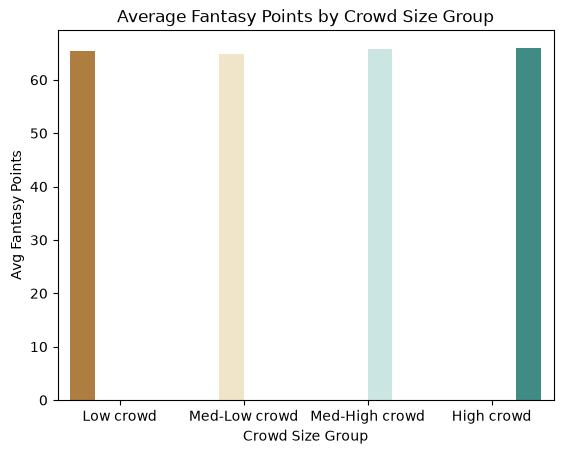

In [53]:
valid = valid.copy()
valid['crowd_bucket'] = pd.qcut(valid['crowd'], 4, labels=['Low crowd','Med-Low crowd','Med-High crowd','High crowd'])
crowd_avg = valid.groupby('crowd_bucket', observed=True)['fantasy_points'].mean()
print(crowd_avg)

sns.barplot(x=crowd_avg.index, y=crowd_avg.values, hue=crowd_avg.index, palette='BrBG', legend=False)
plt.title('Average Fantasy Points by Crowd Size Group')
plt.xlabel('Crowd Size Group')
plt.ylabel('Avg Fantasy Points')
plt.show()

**Finding:** The correlation between crowd size and fantasy points is very close to zero. Splitting crowds into four groups (low to high) shows the average fantasy points barely change between groups, maybe 1 point difference at most. So based on this data, crowd size does not appear to meaningfully influence individual player performance. Bigger games (finals, rivalry matches) naturally draw bigger crowds, but that doesn't seem to translate into players scoring higher or lower.

### Which venues produce the highest average player performance?

In [57]:
venue_counts = rbr_enriched['venue'].value_counts()
# only look at venues with a reasonable sample size so one or two outlier games don't skew things
common_venues = venue_counts[venue_counts >= 500].index

venue_avg = rbr_enriched[rbr_enriched['venue'].isin(common_venues)].groupby('venue')['fantasy_points'].mean().sort_values(ascending=False)
venue_avg

venue
UTAS Stadium                  68.395092
ENGIE Stadium                 67.949394
Marvel Stadium                67.445049
Ninja Stadium                 67.384749
Adelaide Oval                 66.866030
Marvel Stadium\n              66.563013
Optus Stadium                 66.176860
TIO Stadium                   65.979978
People First Stadium          65.910971
Melbourne Cricket Ground\n    65.836041
GMHBA Stadium                 65.665637
Domain Stadium                65.432930
Melbourne Cricket Ground      65.424790
Manuka Oval                   65.231560
Accor Stadium                 65.022131
The Gabba                     63.645760
Sydney Cricket Ground         63.185803
AAMI Stadium                  62.101524
Victoria Park                 61.013755
Waverley Park                 59.460663
Princes Park                  58.879021
Western Oval                  58.796336
WACA                          58.558328
Name: fantasy_points, dtype: float64

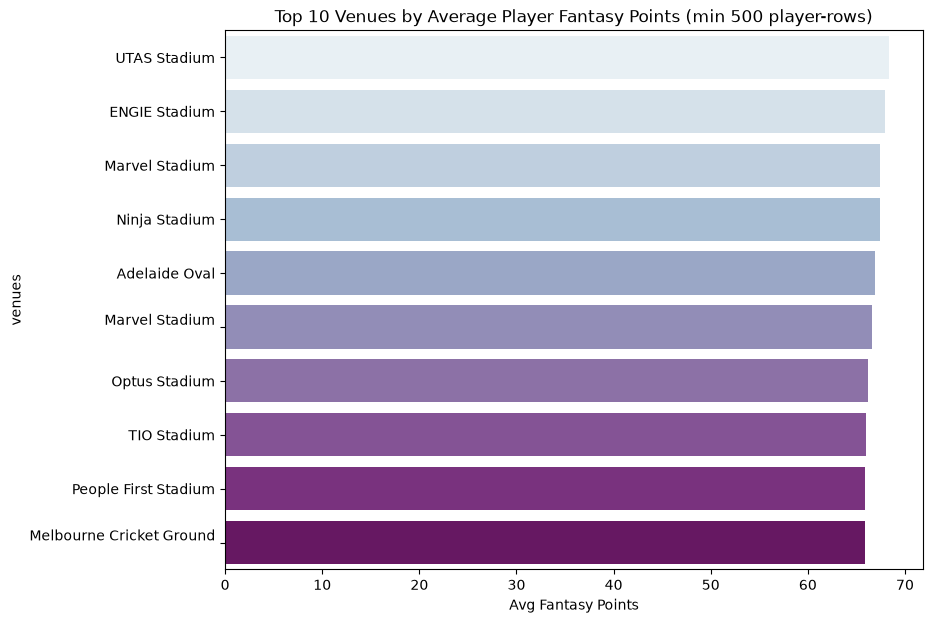

In [61]:
plt.figure(figsize=(9,7))
sns.barplot(y=venue_avg.head(10).index, x=venue_avg.head(10).values, hue=venue_avg.head(10).index, palette='BuPu', legend=False)
plt.title('Top 10 Venues by Average Player Fantasy Points (min 500 player-rows)')
plt.xlabel('Avg Fantasy Points')
plt.ylabel('venues')
plt.show()

**Finding:** There's a real spread between venues, the highest-averaging venues sit around 67-68 fantasy points while the lowest sit closer to 58-60. This could be due to a few things the data itself doesn't fully explain (ground size, era of football played there, which teams play there most often), so I'm not claiming a direct cause, just reporting what the numbers show.

## 7. Task 5: Data Quality Report

**Merge keys used:**
* **team_name** + **match_date**
  
team_name (matches) joined to team (rbr), combined with `match_date` on both sides, as a composite key. I chose this over `team + year + round` because that combination was not unique in the matches dataset.

**Challenges:**
- `team_name` in the matches dataset had inconsistent whitespace/tab characters around several team names, which would have caused those teams to silently fail to merge.
- The Western Bulldogs were labeled `"W. Bulldogs"` in the matches dataset but `"Western Bulldogs"` in the round-by-round dataset, another silent merge failure if left unfixed.
- The `venue` column had trailing newline characters on some rows, which would have split a single venue into two separate categories in the venue analysis if not cleaned.
- `team + year + round` looked like an obvious merge key at first but they had dupes. Using `match_date` instead avoided this problem entirely.
- There were also some d

**Data quality issues discovered:**
- `crowd` has missing values for a portion of matches, mostly older ones, likely because attendance just wasn't recorded consistently in earlier seasons. 
- Team naming was inconsistent across the two datasets and needed standardizing before any merge could work correctly.
- And also the issues mentioned in challenges

**Assumptions made:**
- I assumed `team + match_date` uniquely identifies one match for one team, which I confirmed by checking there were zero duplicate `team_name + match_date` combinations in the matches dataset.
- I assumed missing `crowd` values should be left as missing rather than filled in, since I have no reliable basis in the data itself to estimate them.
- For the venue comparison, I only included venues with at least 500 player-rows in the merged dataset, so a venue that only hosted 1 or 2 games historically doesn't distort the ranking with a tiny sample size.


## 8. Some Insights
1. A single field like round or team name is never unique enough to merge on, needed team + match_date instead.
2. Small naming differences (extra spaces, "W. Bulldogs" vs "Western Bulldogs") cause silent unmatched rows in a merge.
3. team + year + round looked unique but wasn't.
4. Merge was clean: 0 unmatched rows, 0 new duplicates, row count stayed at 274,089 before and after.
5. Found 10 exact duplicate rows already in the raw data (unrelated to the merge) and removed them.
6. Players score slightly higher fantasy points at home than away.
7. Crowd size has almost no effect on individual player fantasy points.
8. Top venues average about 9-10 more fantasy points than the lowest venues.
9. Trailing newline characters in venue names would've split one venue into two if not cleaned.
10. Missing crowd values are a real gap in older matches, left as missing instead of guessed.
11. home_away and venue had zero missing values, but crowd didn't, so data quality varies even within one merged dataset.
